<table>
    <tr>
        <td style="text-align:left">
            <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" alt="Logo Universidad" width="300"/>
        </td>
        <td>
            Departamento de Ciencias de la Computación y de la Decisión<br>
            Facultad de Minas<br>
            Universidad Nacional de Colombia<br>
            Optimizacion e IA 2026-2S<br><br>
            Docente: Maria Constanza Torres Madronero<br>
            <br>
            <b>Estudiante: Juan Gabriel Carvajal Negrete</b><br>
            Documento: 1003713613
        </td>
    </tr>
</table>

# **Práctica 2 - Perceptrón multicapa para regresión (House prices)**

## **Parte 1: Selección del problema**

Escogí el dataset de **House prices** (Ames, Iowa), así que el problema es de **regresión**: predecir el precio de venta (`SalePrice`) de una casa a partir de sus características (área, año de construcción, calidad, garaje, baños, etc.).


In [ ]:
#------ Importacion de librerias -----------#
##-----------------------------------------##
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")


In [ ]:
##---------Carga de datos ------------##
df = pd.read_csv("house_prices.csv")
print("Tamaño del dataset: ", df.shape)
df.head()

Tamaño del dataset:  (1460, 20)


,Id,GrLivArea,YearBuilt,YearRemodAdd,1stFlrSF,2ndFlrSF,HasBasement,TotalBsmtSF,Garage,GarageArea,GarageCars,KitchenQual,TotRmsAbvGrd,BedroomAbvGr,TotalBathrooms,OverallQual,NumFloors,PoolQC,Pool,SalePrice
0,1,1710,2003,2003,856,854,Yes,856,Yes,548,2,Gd,8,3,3.5,7,2,No Pool,No,208500
1,2,1262,1976,1976,1262,0,Yes,1262,Yes,460,2,TA,6,3,2.5,6,1,No Pool,No,181500
2,3,1786,2001,2002,920,866,Yes,920,Yes,608,2,Gd,6,3,3.5,7,2,No Pool,No,223500
3,4,1717,1915,1970,961,756,Yes,756,Yes,642,3,Gd,7,3,2.0,7,2,No Pool,No,140000
4,5,2198,2000,2000,1145,1053,Yes,1145,Yes,836,3,Gd,9,4,3.5,8,2,No Pool,No,250000


**Depuración de la base y primeros descriptivos**

In [ ]:
#-- Revisamos tipos de datos y si hay faltantes --#
print(df.dtypes,"\n")
print("Datos faltantes: ", df.isna().sum().sum())

Id                  int64
GrLivArea           int64
YearBuilt           int64
YearRemodAdd        int64
1stFlrSF            int64
2ndFlrSF            int64
HasBasement        object
TotalBsmtSF         int64
Garage             object
GarageArea          int64
GarageCars          int64
KitchenQual        object
TotRmsAbvGrd        int64
BedroomAbvGr        int64
TotalBathrooms    float64
OverallQual         int64
NumFloors           int64
PoolQC             object
Pool               object
SalePrice           int64
dtype: object 

Datos faltantes:  0


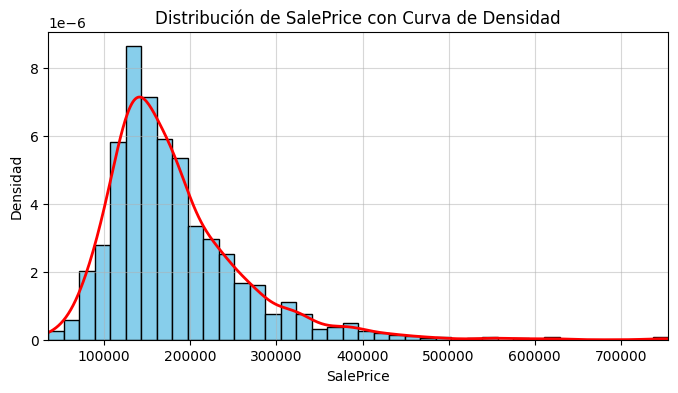

In [ ]:
#Distribucion del precio de venta
ax = df["SalePrice"].plot(kind="hist", bins=40, figsize=(8, 4), \
                          density=True, edgecolor="black", color="skyblue")

df["SalePrice"].plot(kind="kde", ax=ax, color="red", linewidth=2)

plt.title("Distribución de SalePrice con Curva de Densidad")
plt.xlabel("SalePrice")
plt.ylabel("Densidad")
plt.grid(True, alpha=0.5)
plt.xlim(df["SalePrice"].min(), df["SalePrice"].max()) # Ajusta los límites del eje X
plt.show()

No hay datos faltantes, pero revisando el archivo `data_description_updated.txt`  hay algunas columnas de texto que hay que pasar a números antes de meterlas a la red y eliminar algunas columnas que no aportan:

- `HasBasement`, `Garage` y `Pool` son Yes/No → 1/0.
- `KitchenQual` y `PoolQC` son calificaciones, así que uso una escala numérica (el mapping de `KitchenQual` viene en el archivo de descripción de los datos).
- `Id` no aporta nada, lo quitamos.

In [ ]:
#Preprocesamiento de variables categoricas
df = df.drop(columns="Id")

for col_c in ["HasBasement", "Garage", "Pool"]: # Variables categpricas YES/NO
    df[col_c] = df[col_c].replace({"Yes": 1, "No": 0})

kitchen_quality_r = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}
df["KitchenQual"] = df["KitchenQual"].replace(kitchen_quality_r)

pool_quality_r = {"Ex": 4, "Gd": 3, "TA": 2, "Fa": 1, "No Pool": 0}
df["PoolQC"] = df["PoolQC"].replace(pool_quality_r)
df.head()

,GrLivArea,YearBuilt,YearRemodAdd,1stFlrSF,2ndFlrSF,HasBasement,TotalBsmtSF,Garage,GarageArea,GarageCars,KitchenQual,TotRmsAbvGrd,BedroomAbvGr,TotalBathrooms,OverallQual,NumFloors,PoolQC,Pool,SalePrice
0,1710,2003,2003,856,854,1,856,1,548,2,4,8,3,3.5,7,2,0,0,208500
1,1262,1976,1976,1262,0,1,1262,1,460,2,3,6,3,2.5,6,1,0,0,181500
2,1786,2001,2002,920,866,1,920,1,608,2,4,6,3,3.5,7,2,0,0,223500
3,1717,1915,1970,961,756,1,756,1,642,3,4,7,3,2.0,7,2,0,0,140000
4,2198,2000,2000,1145,1053,1,1145,1,836,3,4,9,4,3.5,8,2,0,0,250000


Dejé el precio en **cientos de miles de dólares** (divido entre 100000), igual que viene el target en California housing. Si se deja en dólares el MSE sale en el orden de $10^9$ y las gráficas no se leen.

In [ ]:
#Variables de entrada y salida
x = df.drop(columns="SalePrice").values
y = df["SalePrice"].values / 100000

#Organizacion de los conjuntos de entrenamiento, validacion y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

print("Datos de entrenamiento: ", x_train.shape)
print("Datos de validacion: ", x_valid.shape)
print("Datos de prueba: ", x_test.shape)

Datos de entrenamiento:  (919, 18)
Datos de validacion:  (103, 18)
Datos de prueba:  (438, 18)


In [ ]:
#Normalizacion de los datos
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)
print(x_train[1,:])

[-0.28009742 -1.10946224 -1.66682666 -0.98971747  0.56419241  0.17063218
 -0.6109328   0.23216176 -1.34840812 -1.08897682 -0.7542395   0.29192454
  0.15028508 -0.29122857 -0.08554155  1.14160332 -0.06545058 -0.06611796]


## Parte 2: MLP base - Comparación de optimizadores

Dejé fija la arquitectura para que lo único que cambie sea el optimizador:

- 3 capas ocultas de 60 , 30, 30 neuronas con activación `relu`
- Capa de salida con 1 neurona y sin activación (es regresión)
- Tasa de aprendizaje 0.0001 para todos
- 60 épocas

In [ ]:
#Construccion del MLP base

model = keras.models.Sequential([
        keras.layers.Input(shape=x_train.shape[1:]),
        keras.layers.Dense(60, activation="relu"),
        keras.layers.Dense(30, activation="relu"),
        keras.layers.Dense(30, activation="relu"),
        keras.layers.Dense(1)
    ])

In [ ]:
# Resumen del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 60)             │         1,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,931 (15.36 KB)

 Trainable params: 3,931 (15.36 KB)

 Non-trainable params: 0 (0.00 B)

**Compilación del modelo incial**

In [ ]:
#Vamos a compilar el modelo
model.compile(loss="mean_squared_error",
              optimizer="sgd")

**Entrenamos el modelo con las epocas fijadas**

In [ ]:
history = model.fit(x_train, y_train, epochs=60, validation_data=(x_valid,y_valid))

Epoch 1/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.7979 - val_loss: 0.2496
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2503 - val_loss: 0.2033
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2029 - val_loss: 0.1862
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1782 - val_loss: 0.1802
Epoch 5/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1563 - val_loss: 0.1780
Epoch 6/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1469 - val_loss: 0.1735
Epoch 7/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1338 - val_loss: 0.1624
Epoch 8/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1325 - val_loss: 0.1599
Epoch 9/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1233 - val_loss: 0.1554
Epoch 10/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1187 - val_loss: 0.1638
Epoch 11/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1160 - val_loss: 0.1454
Epoch 12/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1126 - val_l

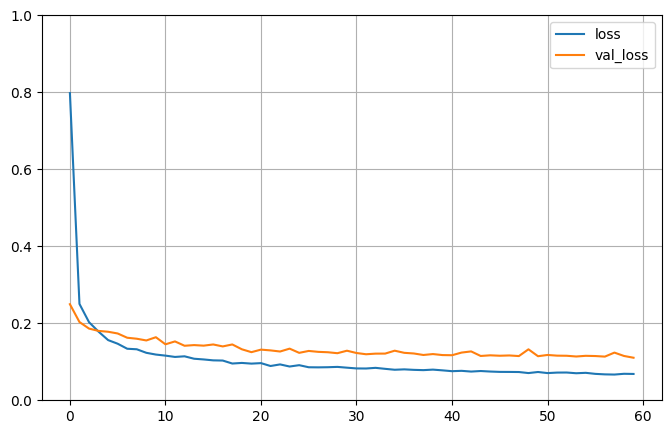

In [ ]:
#Grafica de curva de aprendizaje
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Pasemos a la evaluación del modelo revisando metricas como MAE , MSE, $R^2$

In [ ]:
#Evaluacion del modelo
y_pred=model.predict(x_test)
print("MAE: ", metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ", metrics.mean_squared_error(y_test,y_pred))
print("R2:  ", metrics.r2_score(y_test,y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
MAE:  0.18714123627266382
MSE:  0.08521264097299204
R2:   0.8778855029865322


**Comparación de Optimizadores**

In [ ]:
# Definimos una función para entrenar el modelo con los diferentes optimizadores y ver sus tiempo

def crear_mlp(regularizador=None):
    #Misma semilla para que todos los modelos arranquen con los mismos pesos
    keras.utils.set_random_seed(42)
    model = keras.models.Sequential([
        keras.layers.Input(shape=x_train.shape[1:]),
        keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizador),
        keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizador),
        keras.layers.Dense(1)
    ])
    return model
#Compilacion + entrenamiento, midiendo el tiempo
def entrenar(model, optim, epocas=60):
    model.compile(loss="mean_squared_error", optimizer=optim, metrics=["mse"])
    inicio = time.time()
    history = model.fit(x_train, y_train, epochs=epocas,
                        validation_data=(x_valid, y_valid), verbose=0)
    tiempo = time.time() - inicio
    print("Tiempo de entrenamiento: %.1f s" % tiempo)
    print("MSE entrenamiento: %.4f | MSE validacion: %.4f" % (history.history["mse"][-1], history.history["val_mse"][-1]))
    return history, tiempo

In [ ]:
# SGD
model_sgd = crear_mlp()
history_sgd, tiempo_sgd = entrenar(model_sgd, keras.optimizers.SGD(learning_rate=0.001))

Tiempo de entrenamiento: 13.6 s
MSE entrenamiento: 0.1241 | MSE validacion: 0.1469


In [ ]:
#RMSprop
model_rms = crear_mlp()
history_rms, tiempo_rms = entrenar(model_rms, keras.optimizers.RMSprop(learning_rate=0.001))

Tiempo de entrenamiento: 12.0 s
MSE entrenamiento: 0.0379 | MSE validacion: 0.0959


In [ ]:
#Adam
model_adam = crear_mlp()
history_adam, tiempo_adam = entrenar(model_adam, keras.optimizers.Adam(learning_rate=0.001))

Tiempo de entrenamiento: 12.3 s
MSE entrenamiento: 0.0359 | MSE validacion: 0.1113


In [ ]:
#Resumen de la comparacion
historias = {"SGD": history_sgd,"RMSprop": history_rms, "Adam": history_adam}
tiempos = [tiempo_sgd,tiempo_rms, tiempo_adam]

tabla_opt = pd.DataFrame({
    "Tiempo (s)": tiempos,
    "MSE val final": [h.history["val_mse"][-1] for h in historias.values()],
    "MSE val minimo": [min(h.history["val_mse"]) for h in historias.values()],
    "Epoca del minimo": [np.argmin(h.history["val_mse"]) + 1 for h in historias.values()]
}, index=historias.keys())
tabla_opt.round(4)

,Tiempo (s),MSE val final,MSE val minimo,Epoca del minimo
SGD,13.5602,0.1469,0.1469,60
RMSprop,11.9982,0.0959,0.0885,49
Adam,12.3127,0.1113,0.1112,55


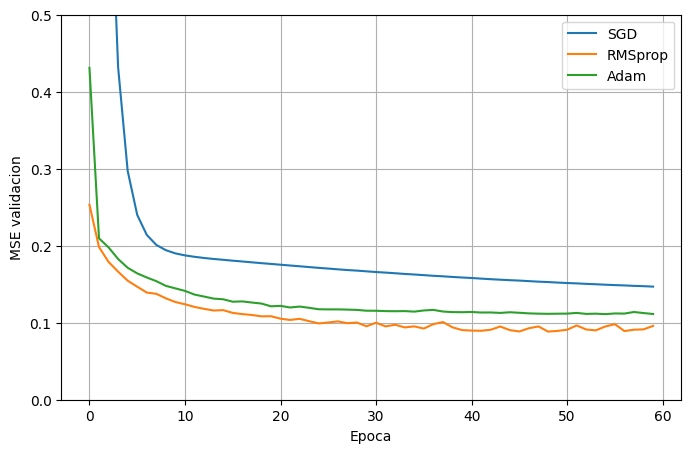

In [ ]:
#Curvas de perdida en validacion
plt.figure(figsize=(8, 5))
for nombre, h in historias.items():
    plt.plot(h.history["val_mse"], label=nombre)
plt.xlabel("Epoca")
plt.ylabel("MSE validacion")
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()

**¿Qué optimizador usar?**

Dado que el optimizador RMSprop es el que logra menor perdida en validación (~ 0.096) y ademas entre los optimizadores usados no hay mucha diferencia entre los terminos de ejecución (11 a 14 segundos), decidimos para el siguiente punto quedarnos con este.


## Parte 3: MLP base - Comparación de regularización

Con la misma arquitectura y el optimizador **RMSprop**, veamos si alguna regularización mejora el resultado: L2, L1, L1-L2 y batch normalization.


In [ ]:
#Sin regularizacion (el modelo base de la parte 2)
model_base = crear_mlp()
history_base, _ = entrenar(model_base, keras.optimizers.RMSprop(learning_rate=0.001))

Tiempo de entrenamiento: 14.0 s
MSE entrenamiento: 0.0379 | MSE validacion: 0.0959


In [ ]:
#Regularizacion L1
model_l1 = crear_mlp(keras.regularizers.l1(0.01))
history_l1, _ = entrenar(model_l1, keras.optimizers.RMSprop(learning_rate=0.001))

Tiempo de entrenamiento: 11.9 s
MSE entrenamiento: 0.1300 | MSE validacion: 0.1346


In [ ]:
#Regularizacion L2
model_l2 = crear_mlp(keras.regularizers.l2(0.01))
history_l2, _ = entrenar(model_l2, keras.optimizers.RMSprop(learning_rate=0.001))

Tiempo de entrenamiento: 13.5 s
MSE entrenamiento: 0.0818 | MSE validacion: 0.1088


In [ ]:
#Regularizacion L1-L2
model_l1l2 = crear_mlp(keras.regularizers.l1_l2(l1=0.001, l2=0.01))
history_l1l2, _ = entrenar(model_l1l2, keras.optimizers.RMSprop(learning_rate=0.001))

Tiempo de entrenamiento: 15.7 s
MSE entrenamiento: 0.0954 | MSE validacion: 0.1242


In [ ]:
#Batch normalization
keras.utils.set_random_seed(42)
model_bn = keras.models.Sequential([
    keras.layers.Input(shape=x_train.shape[1:]),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1)
])
history_bn, _ = entrenar(model_bn, keras.optimizers.RMSprop(learning_rate=0.001))

Tiempo de entrenamiento: 12.7 s
MSE entrenamiento: 0.0304 | MSE validacion: 0.2175


In [ ]:
#Resumen de la comparacion
modelos_reg = {"Sin regularizacion": model_rms, "L2": model_l2, "L1": model_l1,
               "L1-L2": model_l1l2, "BatchNorm": model_bn}
historias_reg = {"Sin regularizacion": history_base, "L2": history_l2, "L1": history_l1,
                 "L1-L2": history_l1l2, "BatchNorm": history_bn}

tabla_reg = pd.DataFrame({
    "MSE train": [h.history["mse"][-1] for h in historias_reg.values()],
    "MSE val": [h.history["val_mse"][-1] for h in historias_reg.values()],
    "MSE test": [m.evaluate(x_test, y_test, verbose=0)[1] for m in modelos_reg.values()]
}, index=modelos_reg.keys())
tabla_reg.round(4)

,MSE train,MSE val,MSE test
Sin regularizacion,0.0379,0.0959,0.1183
L2,0.0818,0.1088,0.0883
L1,0.1300,0.1346,0.1049
L1-L2,0.0954,0.1242,0.0931
BatchNorm,0.0304,0.2175,0.1825


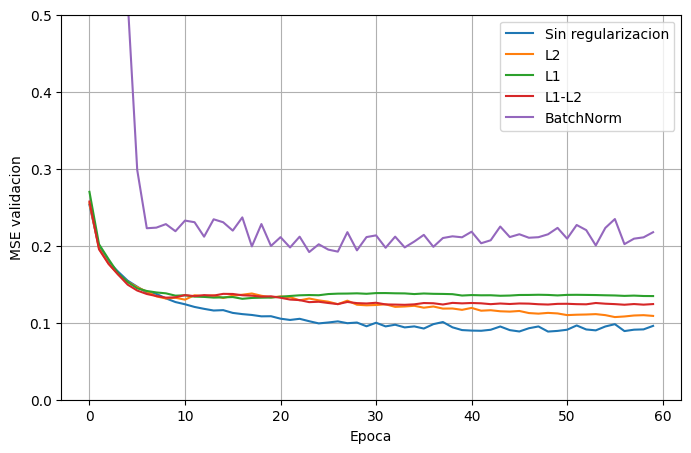

In [ ]:
#Curvas de perdida en validacion
plt.figure(figsize=(8, 5))
for nombre, h in historias_reg.items():
    plt.plot(h.history["val_mse"], label=nombre)
plt.xlabel("Epoca")
plt.ylabel("MSE validacion")
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()

- **L2** es la mejor opción: Consiguió el error de prueba más bajo (0.0883) y la menor brecha entre entrenamiento y validación, controlando eficazmente el sobreajuste.

- **L1 y L1-L2** son menos efectivos: L1 presenta los errores de entrenamiento y validación más altos entre los regularizadores de penalización, y la combinación L1-L2 no logra superar el rendimiento de L2.

- **BatchNorm** fracasa al generalizar: Aunque alcanza el mejor ajuste en entrenamiento (0.0304), sufre de inestabilidad severa en su curva de validación y arroja los peores resultados finales en la prueba.



## Parte 4: Optimización de hiperparámetros

Parto del MLP base con **RMSprop** y uso Keras Tuner para buscar:

- **Número de capas ocultas**: entre 1 y 5
- **Número de neuronas** en cada capa: entre 20 y 120 (de 10 en 10)
- **Tasa de aprendizaje**: 0.01, 0.001 o 0.0001
- **Función de activación** : relu, tanh

Hago 12 pruebas (`max_trials=12`) de 60 épocas cada una, primero con búsqueda aleatoria y luego con optimización bayesiana.

In [ ]:
#Si no esta instalado:
!pip install keras-tuner --upgrade
import keras_tuner as kt

In [ ]:
#Definicion del modelo
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=x_train.shape[1:]))
    #Numero de capas ocultas y neuronas de cada una
    for i in range(hp.Int("num_layers", 1, 5)):
        model.add(keras.layers.Dense(
            units=hp.Int("units_" + str(i), min_value=20, max_value=120, step=10),
             activation=hp.Choice('activation',['relu', 'tanh'])))
    #Capa de salida
    model.add(keras.layers.Dense(1))
    #Paso de aprendizaje
    hp_learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=hp_learning_rate),
                  loss="mean_squared_error",
                  metrics=["mse"])
    return model

### Búsqueda aleatoria

In [ ]:
#Busqueda aleatoria, buscando minimizar la perdida de validacion
tuner_rs = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=12,
    directory="tuner_practica2",
    project_name="random_search",
    seed=42,
)
tuner_rs.search(x_train, y_train, epochs=60, validation_data=(x_valid, y_valid), verbose=0)
tuner_rs.results_summary(num_trials=3)

Reloading Tuner from tuner_practica2/random_search/tuner0.json
Results summary
Results in tuner_practica2/random_search
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 06 summary
Hyperparameters:
num_layers: 1
units_0: 100
activation: relu
learning_rate: 0.001
units_1: 20
units_2: 40
units_3: 20
units_4: 60
Score: 0.09104987233877182

Trial 03 summary
Hyperparameters:
num_layers: 3
units_0: 120
activation: relu
learning_rate: 0.001
units_1: 60
units_2: 20
units_3: 20
units_4: 100
Score: 0.09446161985397339

Trial 00 summary
Hyperparameters:
num_layers: 4
units_0: 20
activation: relu
learning_rate: 0.01
units_1: 20
units_2: 20
units_3: 20
Score: 0.09681467711925507


In [ ]:
#Mostremos los parametros seleccionados
best_hps_rs = tuner_rs.get_best_hyperparameters(num_trials=1)[0]
print(best_hps_rs.values)
best_model_rs = tuner_rs.get_best_models(num_models=1)[0]
best_model_rs.summary()

{'num_layers': 1, 'units_0': 100, 'activation': 'relu', 'learning_rate': 0.001, 'units_1': 20, 'units_2': 40, 'units_3': 20, 'units_4': 60}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

### Optimización bayesiana

In [ ]:
#Optimizacion bayesiana
tuner_bo = kt.BayesianOptimization(
    build_model,
    objective="val_loss",
    max_trials=12,
    num_initial_points=3,
    directory="tuner_practica2",
    project_name="bayesian",
    seed=42,
    overwrite=True
)
tuner_bo.search(x_train, y_train, epochs=60, validation_data=(x_valid, y_valid), verbose=0)
tuner_bo.results_summary(num_trials=3)

Results summary
Results in tuner_practica2/bayesian
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
num_layers: 5
units_0: 20
activation: relu
learning_rate: 0.01
units_1: 20
units_2: 20
units_3: 20
units_4: 120
Score: 0.0896027460694313

Trial 10 summary
Hyperparameters:
num_layers: 5
units_0: 20
activation: relu
learning_rate: 0.01
units_1: 120
units_2: 60
units_3: 20
units_4: 120
Score: 0.09079071879386902

Trial 11 summary
Hyperparameters:
num_layers: 5
units_0: 120
activation: relu
learning_rate: 0.01
units_1: 100
units_2: 120
units_3: 20
units_4: 120
Score: 0.09107334911823273


In [ ]:
#Mostremos los parametros seleccionados
best_hps_bo = tuner_bo.get_best_hyperparameters(num_trials=1)[0]
print(best_hps_bo.values)
best_model_bo = tuner_bo.get_best_models(num_models=1)[0]
best_model_bo.summary()

{'num_layers': 5, 'units_0': 20, 'activation': 'relu', 'learning_rate': 0.01, 'units_1': 20, 'units_2': 20, 'units_3': 20, 'units_4': 120}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,281 (16.72 KB)

 Trainable params: 4,281 (16.72 KB)

 Non-trainable params: 0 (0.00 B)

## Evaluación del desempeño

Se evalúan los modelos (base y optimizados) con datos de prueba inéditos usando las métricas MSE, MAE y $R^2$. Para facilitar su interpretación, el MAE se multiplica por 100,000, lo que refleja el error promedio en dólares.


In [ ]:
#Evaluacion de los modelos en prueba
modelos_finales = {"MLP base": model_base, "Random Search": best_model_rs, "Bayesiana": best_model_bo}
filas = []
for nombre, m in modelos_finales.items():
    y_pred = m.predict(x_test, verbose=0).ravel()
    filas.append([metrics.mean_absolute_error(y_test, y_pred),
                  metrics.mean_squared_error(y_test, y_pred),
                  metrics.r2_score(y_test, y_pred),
                  metrics.mean_absolute_error(y_test, y_pred) * 100000])
tabla_final = pd.DataFrame(filas, index=modelos_finales.keys(),
                           columns=["MAE", "MSE", "R2", "MAE (USD)"])
tabla_final.round(4)

,MAE,MSE,R2,MAE (USD)
MLP base,0.2084,0.1183,0.8305,20842.8574
Random Search,0.1970,0.1109,0.8411,19698.3141
Bayesiana,0.1983,0.0933,0.8663,19832.4576


In [ ]:
#El mejor modelo se escoge con la perdida de validacion (no con prueba)
score_rs = tuner_rs.oracle.get_best_trials(1)[0].score
score_bo = tuner_bo.oracle.get_best_trials(1)[0].score
print("Mejor val_loss Random Search: %.4f | Bayesiana: %.4f" % (score_rs, score_bo))
mejor = "Random Search" if score_rs < score_bo else "Bayesiana"
best_model = modelos_finales[mejor]
y_pred = best_model.predict(x_test, verbose=0).ravel()
print("Mejor modelo:", mejor)
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))
print("MSE: ", metrics.mean_squared_error(y_test, y_pred))
print("R2:  ", metrics.r2_score(y_test, y_pred))

Mejor val_loss Random Search: 0.0910 | Bayesiana: 0.0896
Mejor modelo: Bayesiana
MAE:  0.19832457557264532
MSE:  0.09329935194138123
R2:   0.8662967923079004


## Conclusiones finales

El modelo Bayesiano es la elección más robusta. Aunque Random Search acierta ligeramente mejor en el promedio neto (MAE), el modelo Bayesiano penaliza mejor los errores grandes (MSE) y se ajusta de manera más fiel a la tendencia general de los datos ($R^2$).
